<a href="https://colab.research.google.com/github/karagoz-matias/Data-Science-WPO/blob/main/Exercise_Session_5_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FODS exercise session 5: Linear & Logistic Regression

## Level 7: Linear Regression

**Exercise 24**

Consider the following plot. Given tha the relationship between the y and x-axis given is linear and of the form y= β0 + β1x, what are the values of β0 and β1?

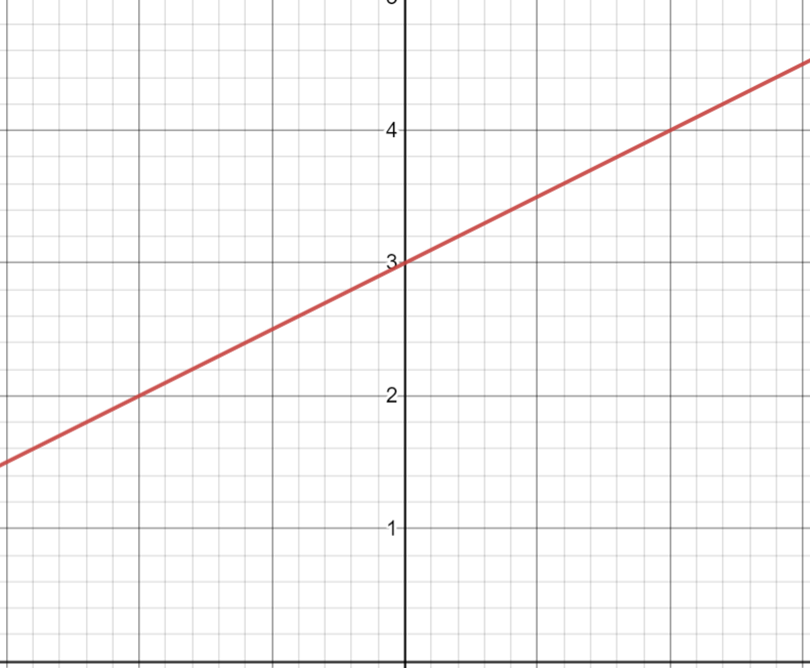


*   Beta0 = 3
*   Beta1 = O,5



**Exercise 25**

Given X and Y generated below. Find the values for the parameters β0 and β1 by solving the normal equation. Compare the result to the "real" parameter values used to generate the data. Does this method work well?

[[4.14921772]
 [2.89867095]]
[[9.75542033]
 [7.32171017]
 [9.78820152]
 [8.29325043]
 [8.19419027]
 [5.40196241]
 [9.80901453]
 [4.18533664]
 [5.61584297]
 [6.66985289]
 [8.66756699]
 [5.29526569]
 [9.15228457]
 [9.85032767]
 [5.09906721]
 [7.61216682]
 [4.2013132 ]
 [6.39030362]
 [4.40522868]
 [9.69526206]
 [6.67770895]
 [9.65076363]
 [8.70770236]
 [9.17139297]
 [5.15311688]
 [4.58372031]
 [7.63192867]
 [5.1230099 ]
 [8.4008733 ]
 [6.51710643]
 [7.20968566]
 [9.58464075]
 [7.17366851]
 [4.77645175]
 [5.06649291]
 [7.3099439 ]
 [7.18936747]
 [7.84566231]
 [6.47682408]
 [7.91636011]
 [6.45018274]
 [7.76627275]
 [8.59812669]
 [5.18679067]
 [6.32655886]
 [7.06257368]
 [8.13006156]
 [5.61988538]
 [7.36524017]
 [7.77215549]
 [9.34074415]
 [6.25280403]
 [7.84535406]
 [5.25909797]
 [7.0351004 ]
 [5.20691611]
 [9.4733982 ]
 [6.65263791]
 [8.96210199]
 [6.56541246]
 [9.39388504]
 [6.49612792]
 [6.06914955]
 [7.46610179]
 [9.05054361]
 [9.14081207]
 [7.6026254 ]
 [4.64003003]
 [7.61177645]
 [5.5

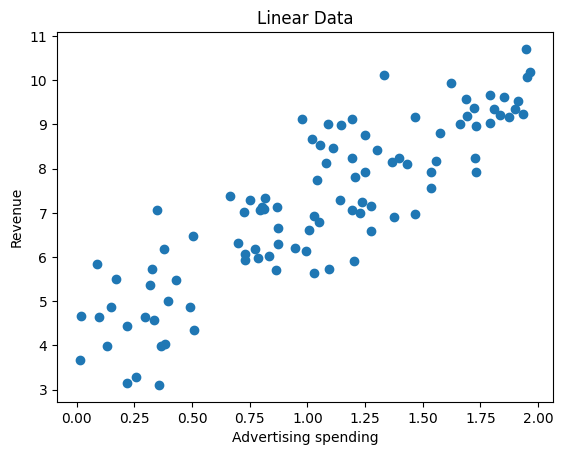

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(4)
X=2*np.random.rand(100,1)
Y=4+3*X+np.random.randn(100,1)

plt.scatter(X,Y)
plt.title("Linear Data")
plt.ylabel("Revenue")
plt.xlabel("Advertising spending")
X_b= np.c_[np.ones((100, 1)), X]

theta_best=np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(Y)

print(theta_best)
estimated_value = theta_best[0] + theta_best[1]*X
print(estimated_value)

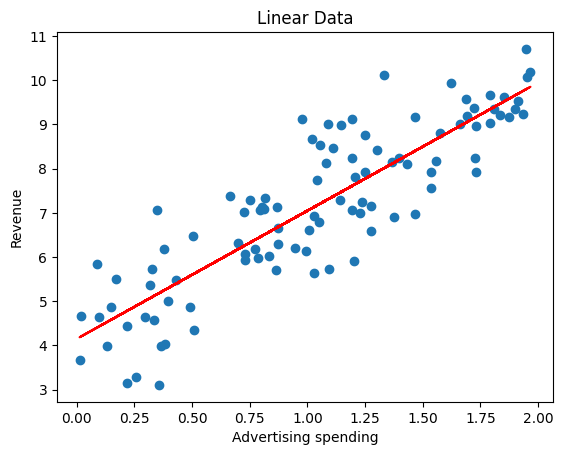

In [3]:
plt.plot(X, estimated_value, "r")
plt.scatter(X,Y)
plt.title("Linear Data")
plt.ylabel("Revenue")
plt.xlabel("Advertising spending")
X_b= np.c_[np.ones((100, 1)), X]

**Exercise 26**

Given the same X and Y as execise 25. Find the values for the parameters by using the "LinearRegression" function provided by Scikit-Learn. Compare the values with those found by solving the normal equation by using the .intercept_ and .coef_ methods.

In [6]:
# First import the Linear Regression function from Scikit-learn
from sklearn.linear_model import LinearRegression

# Initialize and instance of the LinearRegression class.
LR = LinearRegression()

# Apply the fit method (from the Linear Regression function) to the X and Y data.
LR_fit = LR.fit(X,Y)

# Use the .intercept_ and .coef_ methods to extract the estimated parameter values. Compare the result to the parameters obtained by solvind the normal equation and the
B0_new = LR_fit.intercept_
B1_new = LR_fit.coef_
print(LR_fit.intercept_)
print(LR_fit.coef_)


[4.14921772]
[[2.89867095]]


Given new X values, we can now use the fitted parameters to make new predictions by filling in the values in the functional form Y=B0+B1*X.

Text(0.5, 0, 'Advertising spending')

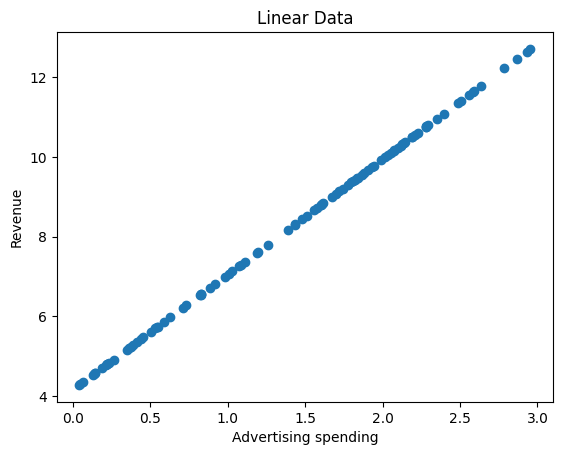

In [12]:
X_new=3*np.random.rand(100,1)

Y_new= B0_new + B1_new*X_new

plt.scatter(X_new,Y_new)

plt.title("Linear Data")
plt.ylabel("Revenue")
plt.xlabel("Advertising spending")

This is exactly what the "predict" method of the LinearRegression model does. Plot it to see that there is no difference.

Text(0.5, 0, 'Advertising spending')

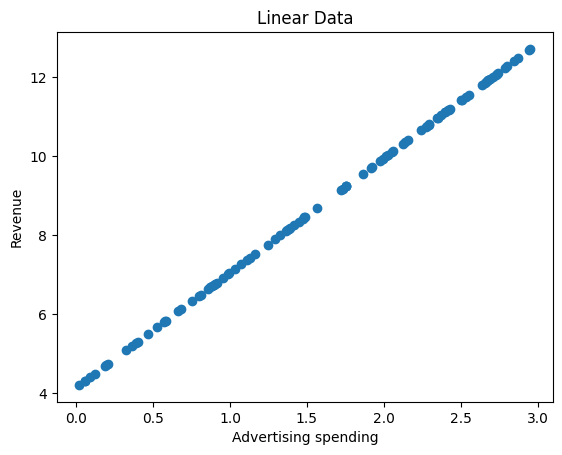

In [10]:
Y_model = LR.predict(X_new)

plt.scatter(X_new,Y_model)

plt.title("Linear Data")
plt.ylabel("Revenue")
plt.xlabel("Advertising spending")

If there was no noise, we would have found the exact parameters with
the help of the normal equation (illustrated below). However, realistic
data is noisy.

**Exercise 27**

In [13]:
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score

# Load the diabetes dataset
diabetes_X, diabetes_y = datasets.load_diabetes(return_X_y=True, as_frame=True)


**27.1:** Check the data quality, is preprocessing necessary?

In [18]:
diabetes_X.isna().sum()
diabetes_X.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


In [15]:
diabetes_y

,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0
...,...
437,178.0
438,104.0
439,132.0
440,220.0


**Step 1) Check for missing values**

**Step 2) Non-numerical values?**

**Step 3) Unscaled Features?**

**27.2**

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error

In [28]:
X_train_di, X_test_di, y_train_di, y_test_di = train_test_split(diabetes_X, diabetes_y, random_state=0)
LR_2 = LinearRegression()
LR_2.fit(X_train_di, y_train_di)
LR_2_pred = LR_2.predict(X_test_di)
R2 = r2_score(y_test_di, LR_2_pred)
print(R2)
MAPE = mean_absolute_percentage_error(y_test_di, LR_2_pred)
print(MAPE)
MAE = mean_squared_error(y_test_di, LR_2_pred)
print(MAE)

0.35940880381777096
0.379610242233884
3180.159648155844


**27.3**

In [30]:
from sklearn.linear_model import Ridge
import numpy as np
MAPE=[]
for alpha in np.arange(0,1,1/10):
  LR_Ridge=Ridge(alpha=alpha)
  LR_Ridge.fit(X_train_di, y_train_di)
  MAPE.append(mean_absolute_percentage_error(y_test_di, LR_Ridge.predict(X_test_di)))
print(MAPE)

[0.37961024223388445, 0.37767748900726494, 0.3752707089785516, 0.3760611732561649, 0.3779199299970178, 0.3804524174184414, 0.38286374280378926, 0.38587197309389126, 0.38907329972277366, 0.392051497725248]


Text(0, 0.5, 'MAPE Unscaled Feat')

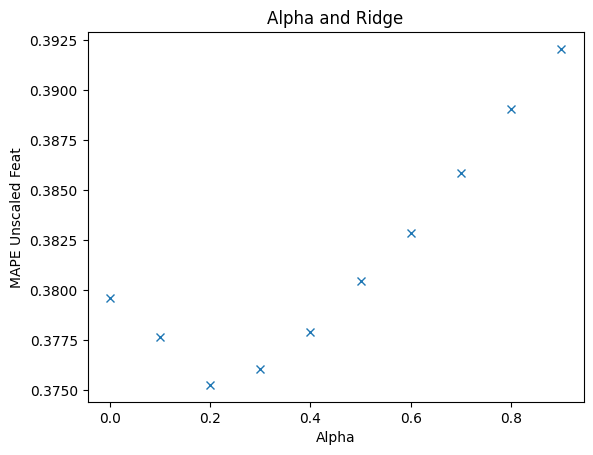

In [31]:
import matplotlib.pyplot as plt

plt.plot(np.arange(0,1, 1/10), MAPE, "x")
plt.title("Alpha and Ridge")
plt.xlabel("Alpha")
plt.ylabel("MAPE Unscaled Feat")

27.4 Optimize the hyperparameter of the Ridge Regression Model in the correct way; forget about the performance on the test set.

In [37]:

from sklearn.model_selection import GridSearchCV


alpha_val=np.arange(0,1,1/10) #adjust the hyperparameter values here

parameters = dict(alpha=alpha_val)

Grid=GridSearchCV(Ridge(), parameters, cv=100, scoring="neg_mean_squared_error", verbose=2)

Grid.best_estimator = Grid.fit(X_train_di, y_train_di)
optimal_model = Grid.best_estimator
optimal_model_pred = optimal_model.predict(X_test_di)
print(mean_absolute_percentage_error(y_test_di,optimal_model_pred))

Fitting 100 folds for each of 10 candidates, totalling 1000 fits
[CV] END ..........................................alpha=0.0; total time=   0.0s
[CV] END ..........................................alpha=0.0; total time=   0.0s
[CV] END ..........................................alpha=0.0; total time=   0.0s
[CV] END ..........................................alpha=0.0; total time=   0.0s
[CV] END ..........................................alpha=0.0; total time=   0.0s
[CV] END ..........................................alpha=0.0; total time=   0.0s
[CV] END ..........................................alpha=0.0; total time=   0.0s
[CV] END ..........................................alpha=0.0; total time=   0.0s
[CV] END ..........................................alpha=0.0; total time=   0.0s
[CV] END ..........................................alpha=0.0; total time=   0.0s
[CV] END ..........................................alpha=0.0; total time=   0.0s
[CV] END ...................................

**Exercise 28**

Interestingly, you can actually use a linear model to fit nonlinear data. To do so, you simply add powers of each feature as new features and then train a linear model on this extended set of features. This technique is called **Polynomial Regression**. Run the cel below and interpret the result. Which values are printed and is the model performing well? Hint: compare the result to the generated data.

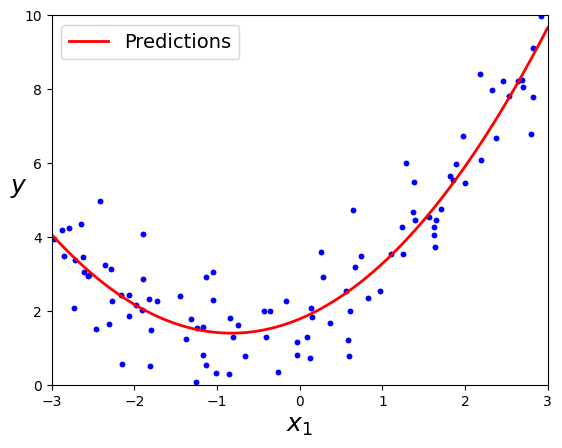

[1.78134581] [[0.93366893 0.56456263]]


In [38]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np
import numpy.random as rnd

#data generation
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)
plt.plot(X, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-3, 3, 0, 10])

#Transform degrees to extra features
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0]

#Perform linear regression as usual
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
X_new=np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.legend(loc="upper left", fontsize=14)
plt.axis([-3, 3, 0, 10])
plt.show()

# Print the estimated coefficients
a_0, a_1=lin_reg.intercept_, lin_reg.coef_

print(a_0, a_1)

## Level 8: Logistic Regression

**Exercise 29**

As an illustration of the new function and its methods, we will use the Logistic Regression function to classify the irises.

In [39]:
from sklearn.datasets import load_iris

X_iris, y_iris=load_iris(as_frame=True, return_X_y=True)

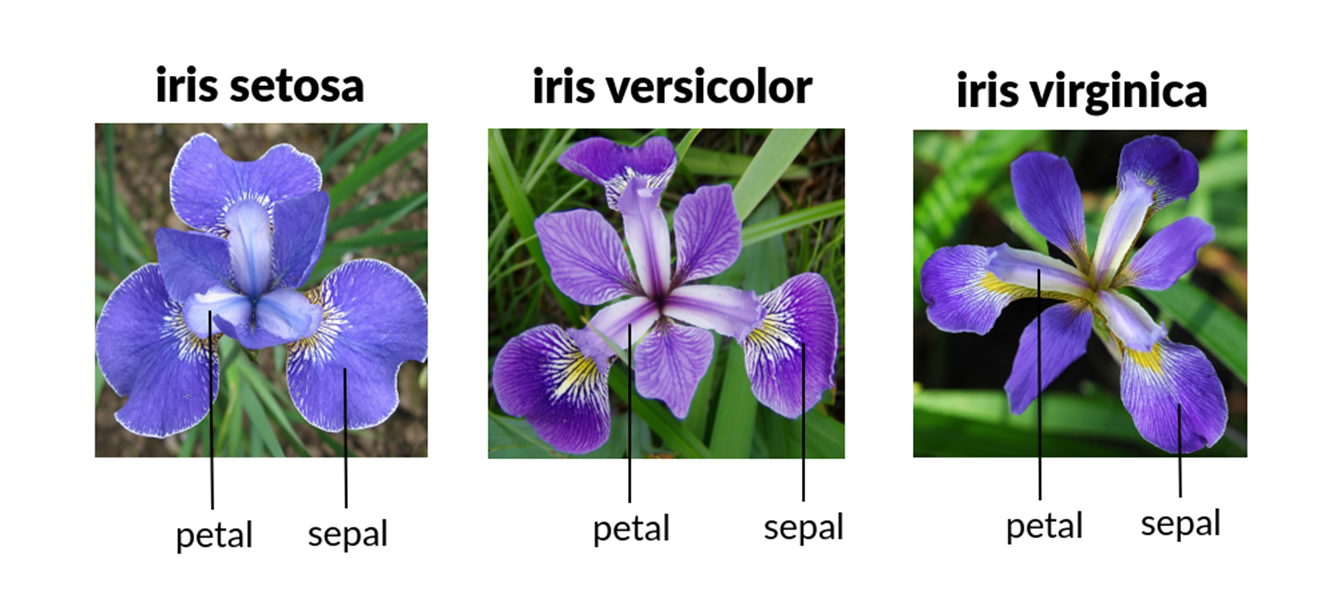

Import the Logisticregression function from sklearn.linear-model.

In [40]:
from sklearn.linear_model import LogisticRegression


Create an instance of the LogisticRegression class (random_state=0). Could we use "ovr" as value for the multi_class parameter? Set the max number of iterations to 1000.

In [42]:
LogR = LogisticRegression(random_state =0, multi_class= "auto", max_iter= 1000)


Split the data into training/test sets. Use the ‘fit’ method of the “LogisticRegression” function to fit the training data.

In [51]:
X_train_log, X_test_log, Y_train_log, Y_test_log =  train_test_split(X_iris, y_iris, random_state=0)
LogR_fit = LogR.fit(X_train_log, Y_train_log)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Use the predict and the predict_proba methods of the trained logistic regression model. What is the difference? Print and compare.

In [63]:
probs_y = LogR_fit.predict_proba(X_test_log)
print(probs_y)
pred_y = LogR_fit.predict(X_test_log)
print(pred_y)

[[1.18229006e-04 5.61893083e-02 9.43692463e-01]
 [1.26916722e-02 9.60435900e-01 2.68724281e-02]
 [9.84424868e-01 1.55750931e-02 3.86790460e-08]
 [1.26575946e-06 2.31727888e-02 9.76825945e-01]
 [9.70193451e-01 2.98063858e-02 1.62899318e-07]
 [2.02644049e-06 5.95766136e-03 9.94040312e-01]
 [9.81887230e-01 1.81126992e-02 7.06637008e-08]
 [2.86496890e-03 7.46591373e-01 2.50543658e-01]
 [1.52291599e-03 7.38097466e-01 2.60379618e-01]
 [2.06353584e-02 9.35746081e-01 4.36185608e-02]
 [9.29753057e-05 1.60649911e-01 8.39257114e-01]
 [7.02691712e-03 8.09747980e-01 1.83225103e-01]
 [4.09636811e-03 7.94286911e-01 2.01616720e-01]
 [3.07917537e-03 7.60575782e-01 2.36345043e-01]
 [3.89163708e-03 7.10864345e-01 2.85244018e-01]
 [9.82767335e-01 1.72326081e-02 5.66744692e-08]
 [6.75155633e-03 7.56755517e-01 2.36492927e-01]
 [1.14217375e-02 8.45987809e-01 1.42590453e-01]
 [9.67527878e-01 3.24719071e-02 2.14682863e-07]
 [9.82914022e-01 1.70859177e-02 5.99127348e-08]
 [8.36673606e-04 1.93878229e-01 8.052850

Evaluate the predicted probabilities by using the cross entropy metric (log_loss from sklearn.metrics).

In [65]:
from sklearn.metrics import log_loss
print(log_loss(Y_test_log,probs_y))

0.17148013874450188


Run the cell below to plot the decision and probability boundaries.

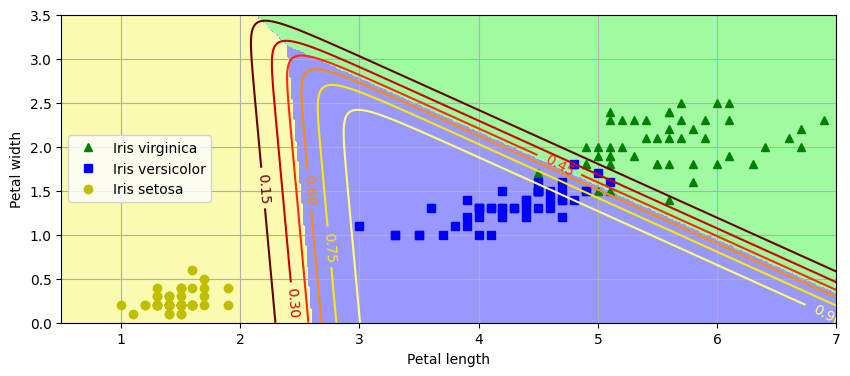

In [66]:
# extra code – this cell generates and saves Figure 4–25
iris=load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

softmax_reg = LogisticRegression(C=30, random_state=42)
softmax_reg.fit(X_train, y_train)
from matplotlib.colors import ListedColormap

custom_cmap = ListedColormap(["#fafab0", "#9898ff", "#a0faa0"])

x0, x1 = np.meshgrid(np.linspace(0, 8, 500).reshape(-1, 1),
                     np.linspace(0, 3.5, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]

y_proba = softmax_reg.predict_proba(X_new)
y_predict = softmax_reg.predict(X_new)

zz1 = y_proba[:, 1].reshape(x0.shape)
zz = y_predict.reshape(x0.shape)

plt.figure(figsize=(10, 4))
plt.plot(X[y == 2, 0], X[y == 2, 1], "g^", label="Iris virginica")
plt.plot(X[y == 1, 0], X[y == 1, 1], "bs", label="Iris versicolor")
plt.plot(X[y == 0, 0], X[y == 0, 1], "yo", label="Iris setosa")

plt.contourf(x0, x1, zz, cmap=custom_cmap)
contour = plt.contour(x0, x1, zz1, cmap="hot")
plt.clabel(contour, inline=1)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="center left")
plt.axis([0.5, 7, 0, 3.5])
plt.grid()

plt.show()